# Token attribution visualization

**Business context:** Stakeholders rarely accept raw attribution vectors. Colored token and bar views make Shapley/Banzhaf results legible in compliance reviews and product postmortems.

**Goal:** Run a tiny exact explain job and render per-token attributions with both built-in renderers.

**Prerequisites:** `nlp-shap[viz]`, Python 3.12.


In [1]:
import matplotlib.pyplot as plt

from nlp_shap import ExplainConfig, ExplainRunner, render_attribution, render_attribution_html
from nlp_shap.domain.conversation import ConversationSnapshot, Message, Turn
from nlp_shap.domain.enums import Role
from nlp_shap.masking.partitions import TokenPartitioner
from nlp_shap.viz import display_attribution_html


## Explain a short refund-policy prompt (mock backend)


In [2]:
snapshot = ConversationSnapshot.from_turns((
    Turn(messages=(Message(role=Role.USER, text="refund within thirty days"),)),
))
config = ExplainConfig.model_validate({
    "backend": {"kind": "mock", "model_id": "stub"},
    "generation": {"max_new_tokens": 6, "temperature": 0.0, "precompute_base": True},
    "explanation": {
        "estimator": "exact",
        "estimand": "shapley",
        "value_fn": "tfidf_cosine",
        "normalizer": "identity",
        "players": "tokens",
        "absence_policy": "pad",
        "budget": {"fraction": 1.0},
        "seed": 0,
    },
})
output = await ExplainRunner(config).explain(snapshot)
player_set = TokenPartitioner().partition(snapshot)
list(zip(player_set.player_ids, output.result.values))


[('52cbdb1ef10bf5b8:0:0:0', 0.20276778617681523),
 ('52cbdb1ef10bf5b8:0:0:1', 0.10569416373025316),
 ('52cbdb1ef10bf5b8:0:0:2', 0.17861186878496496),
 ('52cbdb1ef10bf5b8:0:0:3', 0.2515295738396768)]

## SHAP-style colored tokens


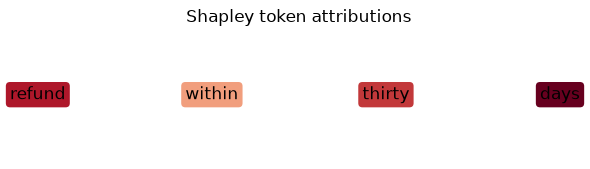

In [3]:
text_fig = render_attribution(output, snapshot, player_set, renderer="token_text")
plt.show()
display_attribution_html(output, snapshot, player_set)


## Horizontal bars sorted by impact


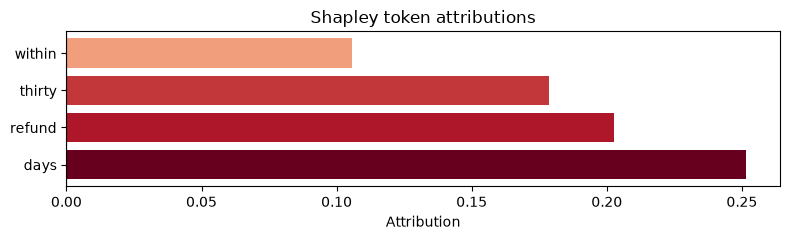

In [4]:
bar_fig = render_attribution(output, snapshot, player_set, renderer="token_bar")
plt.show()
html = render_attribution_html(output, snapshot, player_set, title="Notebook HTML export")
assert "background-color" in html
